# 07 — MMM: ROI Analysis & Budget Optimization

## Objective
Using the causal model fitted in **Notebook 06**, this notebook:
1. **Computes ROI per media channel** — which channels generate the most revenue per dollar spent?
2. **Decomposes revenue** — what portion is driven by media vs baseline vs weather vs seasonality?
3. **Optimizes budget allocation** — how should the budget be reallocated to maximize revenue?
4. **Runs scenario analysis** — what-if analysis for budget changes

## Relationship to Notebook 06
- **NB06 (Causal Inference)**: Fits Ridge regression models, validates with bootstrap/LOOCV, outputs coefficients and effectiveness metrics
- **NB07 (This notebook)**: Loads NB06 outputs, interprets results as ROI, runs optimization

**No model re-fitting here** — we use the validated model from NB06.

## Inputs from Notebook 06
| File | Contents |
|------|----------|
| `media_effectiveness_results.csv` | Marginal effects, ROAS, contribution per channel per product |
| `saturation_curves.csv` | Spend vs incremental revenue curves |
| `causal_model_params.json` | Decay rates, saturation params, Ridge alphas, R², feature names |
| `robustness_summary.csv` | Stability checks for coefficient estimates |

## Key Deliverables
1. **ROI Table** — revenue generated per $1 spent, per channel
2. **Revenue Decomposition** — waterfall chart showing contribution by driver
3. **Marginal ROI Curves** — diminishing returns visualization
4. **Budget Optimization** — recommended reallocation to maximize revenue
5. **Scenario Analysis** — what-if analysis for budget changes

---

## Section 0 — Setup & Load NB06 Outputs

In [ ]:
# ---------- Imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import sys
import warnings
from datetime import datetime

from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')

# Import transformation functions from project source
sys.path.insert(0, str(Path().cwd().parent / 'src' if Path().cwd().name == 'notebooks' else Path().cwd() / 'src'))
from features.transformations import (
    geometric_adstock, hill_saturation, log_saturation,
    power_saturation, hill_derivative
)

# ---------- Plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('husl')

# ---------- Paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path = project_root / 'reports' / 'figures'
reports_path = project_root / 'reports'

figures_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print(f'Project root : {project_root}')
print(f'Processed    : {processed_path}')
print(f'Figures      : {figures_path}')

In [2]:
# ---------- Load NB06 outputs ----------

# 1. Effectiveness results (main deliverable from NB06)
eff_df = pd.read_csv(processed_path / 'media_effectiveness_results.csv')
print(f'✓ Loaded media_effectiveness_results.csv: {eff_df.shape}')

# 2. Saturation curves
sat_curves_df = pd.read_csv(processed_path / 'saturation_curves.csv')
print(f'✓ Loaded saturation_curves.csv: {sat_curves_df.shape}')

# 3. Model parameters
with open(processed_path / 'causal_model_params.json') as f:
    model_params = json.load(f)
print(f'✓ Loaded causal_model_params.json')

# 4. Robustness summary
try:
    robust_df = pd.read_csv(processed_path / 'robustness_summary.csv')
    print(f'✓ Loaded robustness_summary.csv: {robust_df.shape}')
except FileNotFoundError:
    robust_df = None
    print('⚠ robustness_summary.csv not found (optional)')

# 5. Transformation parameters (from NB05)
with open(processed_path / 'optimal_transformation_params.json') as f:
    transform_params = json.load(f)
print(f'✓ Loaded optimal_transformation_params.json')

✓ Loaded media_effectiveness_results.csv: (49, 10)
✓ Loaded saturation_curves.csv: (70, 4)
✓ Loaded causal_model_params.json
✓ Loaded robustness_summary.csv: (7, 5)
✓ Loaded optimal_transformation_params.json


In [ ]:
# ---------- Load raw data for context ----------
try:
    df = pd.read_pickle(processed_path / 'sales_spend_weather.pkl')
except (NotImplementedError, ModuleNotFoundError):
    # Fallback to CSV if pickle has version compatibility issues
    df = pd.read_csv(processed_path / 'sales_spend_weather.csv')
    df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)

print(f'\nDataset: {df.shape[0]} months, {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} — {df["date"].max().date()}')
print(f'Fiscal years: {sorted(df["year"].unique())}')

In [4]:
# ---------- Extract key parameters from NB06 ----------

# Media channels
MEDIA_CHANNELS = ['media_' + ch for ch in model_params['media_channels']]

# Spend column mapping
SPEND_TO_MEDIA = {
    'media_television':          'spend_television',
    'media_radio':               'spend_radio',
    'media_panneaux':            'spend_panneaux',
    'media_social_media':        'spend_social_media',
    'media_preroll':             'spend_preroll',
    'media_banniere_web':        'spend_banniere_web',
    'media_circulaire_digitale': 'spend_circulaire_digitale',
}

# Channel display names
CHANNEL_LABELS = {
    'media_television':          'Television',
    'media_radio':               'Radio',
    'media_panneaux':            'Panneaux (Outdoor)',
    'media_social_media':        'Social Media',
    'media_preroll':             'Preroll (Video)',
    'media_banniere_web':        'Web Banners',
    'media_circulaire_digitale': 'Digital Flyers',
}

# Decay rates and saturation params
DECAY_RATES = {'media_' + k: v for k, v in model_params['decay_rates'].items()}
SATURATION_PARAMS = {'media_' + k: v for k, v in model_params['saturation_params'].items()}

# Model performance
print('Model Performance (from NB06):')
print('-' * 50)
for product, r2 in model_params.get('ridge_r2', {}).items():
    r2_cv = model_params.get('ridge_r2_cv', {}).get(product, 'N/A')
    print(f'  {product:30s}  R²={r2:.3f}  LOOCV R²={r2_cv:.3f}')

Model Performance (from NB06):
--------------------------------------------------
  Total Revenue                   R²=0.966  LOOCV R²=0.912
  Above-Ground Pools (HT)         R²=0.854  LOOCV R²=0.733
  In-Ground Pools (CR)            R²=0.668  LOOCV R²=0.531
  Spas (SP)                       R²=0.929  LOOCV R²=0.855
  Furniture & Gazebo (ME&GA)      R²=0.966  LOOCV R²=0.915
  Fitness (FI)                    R²=0.570  LOOCV R²=0.415
  BBQ (BQ)                        R²=0.958  LOOCV R²=0.887


In [ ]:
# ===================================================================
# STEP 1 — RECONSTRUCT NB06 RESPONSE FUNCTIONS
# ===================================================================
# Following the professor's two-step framework (Teaching.pdf, slides 17-19):
#   Step 1: RESPONSE ESTIMATION — reconstruct the demand/response curves
#           from NB06's Ridge regression pipeline
#   Step 2: CONSTRAINED OPTIMIZATION — later in Section 4
#
# We replicate NB06's exact pipeline to recover:
#   - Unstandardized coefficients (beta_orig)
#   - Per-channel revenue contributions
#   - Channel response functions for optimization

# --- Pre-compute totals (needed for decomposition below) ---
total_revenue = df['total_all_revenue'].sum()
spend_cols_all = [c for c in df.columns if c.startswith('spend_') and c != 'spend_total']
total_spend = df[spend_cols_all].sum().sum()

# --- 1a. Create media columns from spend columns ---
for media_col, spend_col in SPEND_TO_MEDIA.items():
    df[media_col] = df[spend_col].fillna(0)

# --- 1b. Apply adstock transformation ---
ADSTOCK_COLS = []
for ch in MEDIA_CHANNELS:
    ch_short = ch.replace('media_', '')
    decay = DECAY_RATES[ch]
    df[f'{ch}_adstock'] = geometric_adstock(df[ch].values, decay)
    ADSTOCK_COLS.append(f'{ch}_adstock')

# --- 1c. Apply saturation transformation ---
SATURATED_COLS = []
for ch in MEDIA_CHANNELS:
    adstock_col = f'{ch}_adstock'
    sat_p = SATURATION_PARAMS[ch]
    
    if sat_p['type'] == 'hill':
        df[f'{ch}_saturated'] = hill_saturation(
            df[adstock_col].values, K=sat_p['K'], alpha=sat_p.get('alpha', 2)
        )
    elif sat_p['type'] == 'log':
        df[f'{ch}_saturated'] = log_saturation(
            df[adstock_col].values, scale=sat_p.get('scale', 1)
        )
    elif sat_p['type'] == 'power':
        df[f'{ch}_saturated'] = power_saturation(
            df[adstock_col].values, beta=sat_p.get('beta', 0.5)
        )
    SATURATED_COLS.append(f'{ch}_saturated')

# --- 1d. Create control features (Fourier + weather) ---
df['sin_1'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['cos_1'] = np.cos(2 * np.pi * df['month_num'] / 12)
df['sin_2'] = np.sin(4 * np.pi * df['month_num'] / 12)
df['cos_2'] = np.cos(4 * np.pi * df['month_num'] / 12)

for wcol in ['total_sunshine_hours', 'total_precipitation', 'days_above_25']:
    df[f'{wcol}_scaled'] = (df[wcol] - df[wcol].mean()) / df[wcol].std()

CONTROL_COLS = ['sin_1', 'cos_1', 'sin_2', 'cos_2',
                'total_sunshine_hours_scaled', 'total_precipitation_scaled',
                'days_above_25_scaled']

FEATURE_COLS = SATURATED_COLS + CONTROL_COLS

# --- 1e. Standardize features and fit Ridge (exactly as NB06) ---
np.random.seed(42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].fillna(0))

target = 'total_all_revenue'
y = df[target].values

best_alpha = model_params['ridge_alphas']['Total Revenue']
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_scaled, y)

# --- 1f. Verify coefficients match NB06 ---
saved_coefs = {row['channel']: row['ridge_coef_std']
               for _, row in eff_df[eff_df['product'] == 'Total Revenue'].iterrows()}

print('Coefficient Verification (reconstructed vs NB06 saved):')
print('-' * 65)
max_diff = 0
for ch in model_params['media_channels']:
    feat_idx = FEATURE_COLS.index(f'media_{ch}_saturated')
    reconstructed = ridge_model.coef_[feat_idx]
    saved = saved_coefs.get(ch, 0)
    diff = abs(reconstructed - saved)
    max_diff = max(max_diff, diff)
    match = 'OK' if diff < 1e-3 else 'MISMATCH'
    print(f'  {ch:25s}  recon={reconstructed:>14.4f}  saved={saved:>14.4f}  [{match}]')
print(f'\nMax difference: {max_diff:.2e}')

# --- 1g. Unstandardize coefficients ---
# Since X was standardized but y was NOT:
#   y = intercept + sum(beta_std_j * (X_j - mean_j) / std_j)
#     = [intercept - sum(beta_std_j * mean_j / std_j)] + sum(beta_orig_j * X_j)
#   where beta_orig_j = beta_std_j / std(X_j)
#
# The adjusted intercept absorbs the mean-centering effect:
#   adjusted_intercept = intercept - sum(beta_orig_j * mean_j)
# So: y = adjusted_intercept + sum(beta_orig_j * X_j)

BETA_ORIG = {}
CONTRIBUTION = {}
CONTRIBUTION_MONTHLY = {}

for i, ch in enumerate(MEDIA_CHANNELS):
    feat_idx = FEATURE_COLS.index(f'{ch}_saturated')
    beta_std = ridge_model.coef_[feat_idx]
    feat_std = scaler.scale_[feat_idx]
    
    beta_orig = beta_std / feat_std if feat_std > 0 else 0
    BETA_ORIG[ch] = beta_orig
    
    # Total contribution over 36 months
    sat_values = df[f'{ch}_saturated'].values
    CONTRIBUTION[ch] = beta_orig * sat_values.sum()
    CONTRIBUTION_MONTHLY[ch] = beta_orig * sat_values.mean()

# Controls contribution
CONTROL_CONTRIB = 0
for col in CONTROL_COLS:
    feat_idx = FEATURE_COLS.index(col)
    beta_orig_ctrl = ridge_model.coef_[feat_idx] / scaler.scale_[feat_idx]
    CONTROL_CONTRIB += beta_orig_ctrl * df[col].sum()

TOTAL_MEDIA_CONTRIBUTION = sum(CONTRIBUTION.values())

# Adjusted baseline: intercept in the unstandardized space
# adjusted_intercept = intercept - sum_j(beta_orig_j * mean_j_raw)
adj_intercept = ridge_model.intercept_
for j in range(len(FEATURE_COLS)):
    adj_intercept -= (ridge_model.coef_[j] / scaler.scale_[j]) * scaler.mean_[j]

BASELINE = adj_intercept * len(df)
PREDICTED_TOTAL = ridge_model.predict(X_scaled).sum()

# --- 1h. Print decomposition ---
print('\n' + '=' * 70)
print('REVENUE DECOMPOSITION (Reconstructed from NB06 Pipeline)')
print('=' * 70)
print(f'  Predicted Total (36 mo):   ${PREDICTED_TOTAL:>15,.0f}')
print(f'  Actual Total (36 mo):      ${total_revenue:>15,.0f}')
print(f'  Residual:                  ${total_revenue - PREDICTED_TOTAL:>15,.0f}')
print()
print(f'  Baseline (adj. intercept): ${BASELINE:>15,.0f}  ({BASELINE/PREDICTED_TOTAL*100:.1f}%)')
print(f'  Controls (season+weather): ${CONTROL_CONTRIB:>15,.0f}  ({CONTROL_CONTRIB/PREDICTED_TOTAL*100:.1f}%)')
print(f'  Total Media Contribution:  ${TOTAL_MEDIA_CONTRIBUTION:>15,.0f}  ({TOTAL_MEDIA_CONTRIBUTION/PREDICTED_TOTAL*100:.1f}%)')
print()
for ch in MEDIA_CHANNELS:
    label = CHANNEL_LABELS.get(ch, ch)
    print(f'    {label:25s}  ${CONTRIBUTION[ch]:>12,.0f}  ({CONTRIBUTION[ch]/PREDICTED_TOTAL*100:.1f}%)')
print()
decomp_sum = BASELINE + CONTROL_CONTRIB + TOTAL_MEDIA_CONTRIBUTION
print(f'  Decomposition Sum:         ${decomp_sum:>15,.0f}')
print(f'  Decomposition Check:       {"PASS" if abs(decomp_sum - PREDICTED_TOTAL) < 1 else "FAIL"}')

In [ ]:
# ===================================================================
# STEP 1 (cont.) — CHANNEL RESPONSE FUNCTIONS
# ===================================================================
# These are the "demand curves" from the professor's framework (slides 20-23).
# Each function maps monthly spend → monthly revenue contribution.
#
# Pipeline: spend → steady-state adstock → saturation → beta_orig × saturated

def channel_response(spend, ch):
    """
    Map monthly spend for a channel to monthly revenue contribution.
    
    Parameters
    ----------
    spend : float
        Monthly spend in dollars
    ch : str
        Channel name (e.g., 'media_television')
    
    Returns
    -------
    float
        Monthly revenue contribution in dollars
    """
    if spend <= 0:
        return 0.0
    
    decay = DECAY_RATES[ch]
    sat_p = SATURATION_PARAMS[ch]
    beta = BETA_ORIG[ch]
    
    # Steady-state adstock: if you spend $X every month, adstock converges to X/(1-decay)
    adstocked = spend / (1 - decay)
    
    # Apply saturation
    if sat_p['type'] == 'hill':
        saturated = float(hill_saturation(np.array([adstocked]), K=sat_p['K'], alpha=sat_p.get('alpha', 2))[0])
    elif sat_p['type'] == 'log':
        saturated = float(log_saturation(np.array([adstocked]), scale=sat_p.get('scale', 1))[0])
    elif sat_p['type'] == 'power':
        saturated = float(power_saturation(np.array([adstocked]), beta=sat_p.get('beta', 0.5))[0])
    else:
        saturated = 0.0
    
    return beta * saturated


def total_response(spend_dict):
    """Total monthly revenue from all media channels given spend allocation."""
    return sum(channel_response(spend, ch) for ch, spend in spend_dict.items())


# Pre-compute current spend per channel (needed for verification and later cells)
current_spend = {}
for ch in model_params['media_channels']:
    spend_col = SPEND_TO_MEDIA.get('media_' + ch)
    if spend_col and spend_col in df.columns:
        current_spend[ch] = df[spend_col].mean()
    else:
        current_spend[ch] = 0

# Verify: response at current monthly spend should approximately match
# the monthly contribution we computed from the data
print('Channel Response Verification:')
print(f'{"Channel":25s} {"Data Contrib/mo":>15s} {"Response(curr)":>15s} {"Ratio":>8s}')
print('-' * 70)
for ch in MEDIA_CHANNELS:
    label = CHANNEL_LABELS.get(ch, ch)
    ch_short = ch.replace('media_', '')
    curr_spend = current_spend.get(ch_short, 0)
    resp = channel_response(curr_spend, ch)
    data_contrib = CONTRIBUTION_MONTHLY[ch]
    ratio = resp / data_contrib if abs(data_contrib) > 1 else float('nan')
    print(f'  {label:23s}  ${data_contrib:>12,.0f}  ${resp:>12,.0f}  {ratio:>7.2f}')

print(f'\nNote: Ratios differ because data uses actual monthly adstock (time-varying)')
print(f'      while response() uses steady-state adstock assumption.')

In [ ]:
# ===================================================================
# STEP 1 (cont.) — RECOMPUTE SATURATION PERCENTAGES
# ===================================================================
# Universal formula that works for Hill, Power, and Log:
#   sat_pct = (S(median_adstock) - S(0)) / (S(max_adstock) - S(0)) * 100
# Always bounded [0, 100%].

SATURATION_PCT = {}

print('Saturation Percentages (Recomputed):')
print('-' * 60)
for ch in MEDIA_CHANNELS:
    label = CHANNEL_LABELS.get(ch, ch)
    sat_p = SATURATION_PARAMS[ch]
    
    adstock_vals = df[f'{ch}_adstock'].values
    adstock_nz = adstock_vals[adstock_vals > 0]
    
    if len(adstock_nz) == 0:
        SATURATION_PCT[ch] = 0.0
        print(f'  {label:25s}  0.0% (no spend)')
        continue
    
    median_adstock = float(np.median(adstock_nz))
    max_adstock = float(np.max(adstock_nz))
    
    # Compute saturation at 0, median, and max
    def sat_func(x):
        x_arr = np.array([x])
        if sat_p['type'] == 'hill':
            return float(hill_saturation(x_arr, K=sat_p['K'], alpha=sat_p.get('alpha', 2))[0])
        elif sat_p['type'] == 'log':
            return float(log_saturation(x_arr, scale=sat_p.get('scale', 1))[0])
        elif sat_p['type'] == 'power':
            return float(power_saturation(x_arr, beta=sat_p.get('beta', 0.5))[0])
        return 0.0
    
    s_0 = sat_func(0)
    s_med = sat_func(median_adstock)
    s_max = sat_func(max_adstock)
    
    if s_max - s_0 > 0:
        pct = (s_med - s_0) / (s_max - s_0) * 100
    else:
        pct = 0.0
    
    SATURATION_PCT[ch] = pct
    print(f'  {label:25s}  {pct:>5.1f}%  (type={sat_p["type"]})')

print('\nAll values bounded [0, 100%].')

In [5]:
# ---------- Compute totals from raw data ----------

# Total revenue
total_revenue = df['total_all_revenue'].sum()
avg_monthly_revenue = df['total_all_revenue'].mean()

# Total spend
spend_cols = [c for c in df.columns if c.startswith('spend_') and c != 'spend_total']
total_spend = df[spend_cols].sum().sum()
avg_monthly_spend = total_spend / len(df)

print('3-Year Summary:')
print(f'  Total Revenue:       ${total_revenue:>15,.0f}')
print(f'  Avg Monthly Revenue: ${avg_monthly_revenue:>15,.0f}')
print(f'  Total Media Spend:   ${total_spend:>15,.0f}')
print(f'  Avg Monthly Spend:   ${avg_monthly_spend:>15,.0f}')
print(f'  Overall ROAS:        {total_revenue / total_spend:>15.2f}')

3-Year Summary:
  Total Revenue:       $    512,411,602
  Avg Monthly Revenue: $     14,233,656
  Total Media Spend:   $     10,257,505
  Avg Monthly Spend:   $        284,931
  Overall ROAS:                  49.95


---
## Section 1 — ROI Analysis (from NB06 Effectiveness Results)

In [ ]:
# ===================================================================
# 1-A  ROI ANALYSIS WITH RECONSTRUCTED CONTRIBUTIONS
# ===================================================================

# Focus on Total Revenue
eff_total = eff_df[eff_df['product'] == 'Total Revenue'].copy()

roi_data = []
for _, row in eff_total.iterrows():
    ch = 'media_' + row['channel']
    label = CHANNEL_LABELS.get(ch, row['channel'])
    
    roi_data.append({
        'channel': ch,
        'label': label,
        'total_spend': row['total_spend'],
        'marginal_per_1000': row['marginal_per_1000'],
        'marginal_ci_lo': row['marginal_ci_lo'],
        'marginal_ci_hi': row['marginal_ci_hi'],
        'roas': row['roas'],
        'total_contribution': CONTRIBUTION[ch],          # FIXED: from reconstructed pipeline
        'saturation_pct': SATURATION_PCT[ch],             # FIXED: bounded [0, 100%]
        'ridge_coef': row['ridge_coef_std'],
    })

roi_df = pd.DataFrame(roi_data)

# Compute shares using reconstructed contributions
roi_df['spend_share'] = roi_df['total_spend'] / roi_df['total_spend'].sum()
positive_contrib = roi_df['total_contribution'].clip(lower=0).sum()
roi_df['contrib_share'] = np.where(
    positive_contrib > 0,
    roi_df['total_contribution'].clip(lower=0) / positive_contrib,
    0
)

# Efficiency index
roi_df['efficiency_index'] = roi_df['contrib_share'] / roi_df['spend_share'].replace(0, np.nan)

# Sort by ROAS
roi_df = roi_df.sort_values('roas', ascending=False).reset_index(drop=True)

print('=' * 110)
print('ROI ANALYSIS BY CHANNEL (Total Revenue) — Reconstructed Contributions')
print('=' * 110)
print(f'{"Channel":25s} {"Spend":>12s} {"Spend%":>8s} {"ROAS":>8s} {"$/1K":>10s} {"90% CI":>20s} {"Contrib (3Y)":>14s} {"Sat%":>6s}')
print('-' * 110)
for _, row in roi_df.iterrows():
    ci_str = f"[{row['marginal_ci_lo']:>6.0f}, {row['marginal_ci_hi']:>6.0f}]"
    roas_str = f"{row['roas']:.1f}" if row['roas'] > 0 else 'N/A'
    print(f"{row['label']:25s} ${row['total_spend']:>10,.0f} {row['spend_share']*100:>7.1f}% {roas_str:>8s} ${row['marginal_per_1000']:>8,.0f} {ci_str:>20s} ${row['total_contribution']:>12,.0f} {row['saturation_pct']:>5.1f}%")
print('-' * 110)
print(f"{'TOTAL':25s} ${roi_df['total_spend'].sum():>10,.0f} {'':>8s} {'':>8s} {'':>10s} {'':>20s} ${roi_df['total_contribution'].sum():>12,.0f}")

In [7]:
# ===================================================================
# 1-B  ROI INTERPRETATION
# ===================================================================

print('\nROI INTERPRETATION:')
print('=' * 70)
print('\nROAS (Return on Ad Spend) = Marginal revenue per $1 spent')
print('  - ROAS > 1: Channel generates more revenue than it costs')
print('  - ROAS < 1: Channel costs more than incremental revenue')
print('  - ROAS < 0: Channel has negative association (confounding likely)')
print()

# Categorize channels
high_roi = roi_df[roi_df['roas'] > 1]['label'].tolist()
moderate_roi = roi_df[(roi_df['roas'] > 0) & (roi_df['roas'] <= 1)]['label'].tolist()
negative_roi = roi_df[roi_df['roas'] <= 0]['label'].tolist()

print('Channel Categories:')
print(f'  ✓ High ROI (ROAS > 1):       {high_roi if high_roi else "None"}')
print(f'  ~ Moderate ROI (0 < ROAS ≤ 1): {moderate_roi if moderate_roi else "None"}')
print(f'  ✗ Negative/Zero ROI:         {negative_roi if negative_roi else "None"}')

# Check statistical significance (CI excludes zero)
print('\nStatistical Significance (90% CI excludes zero):')
for _, row in roi_df.iterrows():
    sig = 'Yes' if (row['marginal_ci_lo'] > 0 or row['marginal_ci_hi'] < 0) else 'No'
    print(f"  {row['label']:25s}  {sig}")


ROI INTERPRETATION:

ROAS (Return on Ad Spend) = Marginal revenue per $1 spent
  - ROAS > 1: Channel generates more revenue than it costs
  - ROAS < 1: Channel costs more than incremental revenue
  - ROAS < 0: Channel has negative association (confounding likely)

Channel Categories:
  ✓ High ROI (ROAS > 1):       ['Preroll (Video)', 'Social Media', 'Panneaux (Outdoor)', 'Radio', 'Web Banners']
  ~ Moderate ROI (0 < ROAS ≤ 1): None
  ✗ Negative/Zero ROI:         ['Television', 'Digital Flyers']

Statistical Significance (90% CI excludes zero):
  Preroll (Video)            Yes
  Social Media               No
  Panneaux (Outdoor)         No
  Radio                      No
  Web Banners                No
  Television                 No
  Digital Flyers             No


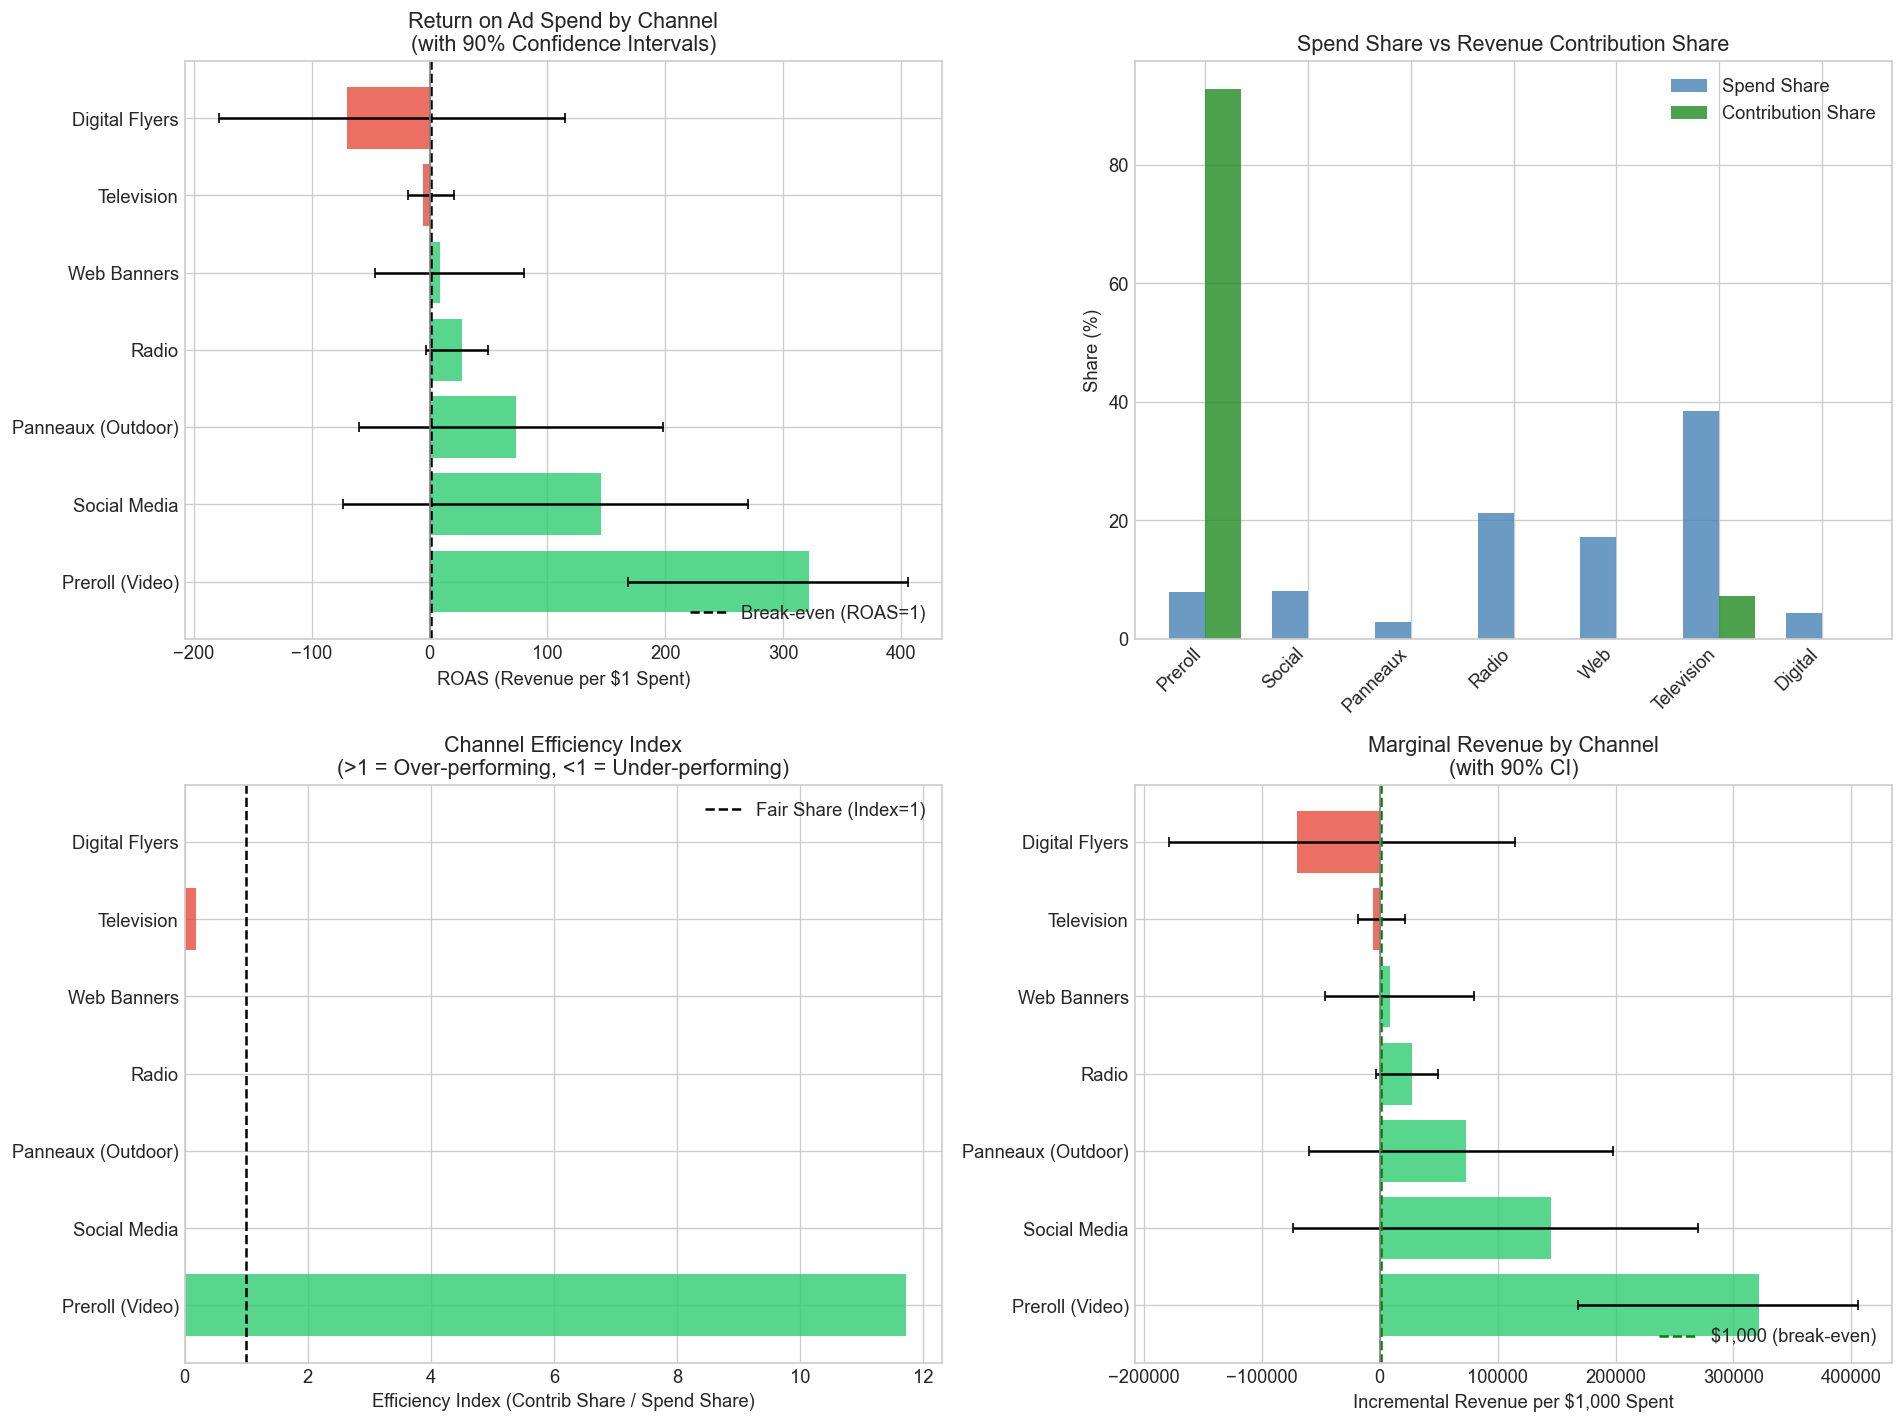

In [8]:
# ===================================================================
# 1-C  ROI VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROAS Bar Chart with CI
ax = axes[0, 0]
y_pos = np.arange(len(roi_df))
colors = ['#2ecc71' if r > 1 else '#f39c12' if r > 0 else '#e74c3c' for r in roi_df['roas']]
bars = ax.barh(y_pos, roi_df['roas'], color=colors, alpha=0.8)

# Add error bars from marginal CI (scaled to ROAS units)
ci_lo_roas = roi_df['marginal_ci_lo'] / 1000
ci_hi_roas = roi_df['marginal_ci_hi'] / 1000
xerr = [roi_df['roas'] - ci_lo_roas, ci_hi_roas - roi_df['roas']]
ax.errorbar(roi_df['roas'], y_pos, xerr=xerr, fmt='none', ecolor='black', capsize=3)

ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='Break-even (ROAS=1)')
ax.axvline(0, color='gray', linestyle='-', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(roi_df['label'])
ax.set_xlabel('ROAS (Revenue per $1 Spent)')
ax.set_title('Return on Ad Spend by Channel\n(with 90% Confidence Intervals)')
ax.legend(loc='lower right')

# 2. Spend Share vs Contribution Share
ax = axes[0, 1]
x = np.arange(len(roi_df))
width = 0.35
ax.bar(x - width/2, roi_df['spend_share'] * 100, width, label='Spend Share', color='steelblue', alpha=0.8)
ax.bar(x + width/2, roi_df['contrib_share'] * 100, width, label='Contribution Share', color='forestgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([l.split()[0] for l in roi_df['label']], rotation=45, ha='right')
ax.set_ylabel('Share (%)')
ax.set_title('Spend Share vs Revenue Contribution Share')
ax.legend()

# 3. Efficiency Index
ax = axes[1, 0]
colors = ['#2ecc71' if e > 1 else '#e74c3c' for e in roi_df['efficiency_index'].fillna(0)]
bars = ax.barh(roi_df['label'], roi_df['efficiency_index'].fillna(0), color=colors, alpha=0.8)
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='Fair Share (Index=1)')
ax.set_xlabel('Efficiency Index (Contrib Share / Spend Share)')
ax.set_title('Channel Efficiency Index\n(>1 = Over-performing, <1 = Under-performing)')
ax.legend()

# 4. Marginal Revenue per $1,000
ax = axes[1, 1]
colors = ['#2ecc71' if m > 1000 else '#f39c12' if m > 0 else '#e74c3c' for m in roi_df['marginal_per_1000']]
bars = ax.barh(roi_df['label'], roi_df['marginal_per_1000'], color=colors, alpha=0.8)

# Add CI whiskers
ax.errorbar(roi_df['marginal_per_1000'], np.arange(len(roi_df)),
            xerr=[roi_df['marginal_per_1000'] - roi_df['marginal_ci_lo'],
                  roi_df['marginal_ci_hi'] - roi_df['marginal_per_1000']],
            fmt='none', ecolor='black', capsize=3)
ax.axvline(1000, color='green', linestyle='--', linewidth=1.5, label='$1,000 (break-even)')
ax.axvline(0, color='gray', linestyle='-', linewidth=1)
ax.set_xlabel('Incremental Revenue per $1,000 Spent')
ax.set_title('Marginal Revenue by Channel\n(with 90% CI)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(figures_path / 'mmm_roi_analysis.png', dpi=150)
plt.show()

---
## Section 2 — Revenue Decomposition

In [ ]:
# ===================================================================
# 2-A  REVENUE DECOMPOSITION (RECONSTRUCTED)
# ===================================================================

# Use values from the reconstructed pipeline (Step 1)
residual = total_revenue - PREDICTED_TOTAL

print('Revenue Decomposition (3-Year Total):')
print('=' * 70)
print(f'  Actual Total Revenue:      ${total_revenue:>15,.0f}')
print(f'  Model Predicted Total:     ${PREDICTED_TOTAL:>15,.0f}')
print(f'  Residual (unexplained):    ${residual:>15,.0f}  ({residual/total_revenue*100:.1f}%)')
print()
print(f'  Breakdown of Predicted:')
print(f'    Baseline (intercept):    ${BASELINE:>15,.0f}  ({BASELINE/PREDICTED_TOTAL*100:.1f}%)')
print(f'    Controls (season+wx):    ${CONTROL_CONTRIB:>15,.0f}  ({CONTROL_CONTRIB/PREDICTED_TOTAL*100:.1f}%)')
print(f'    Media Contribution:      ${TOTAL_MEDIA_CONTRIBUTION:>15,.0f}  ({TOTAL_MEDIA_CONTRIBUTION/PREDICTED_TOTAL*100:.1f}%)')
print()
print(f'  Media Channel Detail:')
for ch in sorted(MEDIA_CHANNELS, key=lambda c: CONTRIBUTION[c], reverse=True):
    label = CHANNEL_LABELS.get(ch, ch)
    contrib = CONTRIBUTION[ch]
    print(f'    {label:25s}  ${contrib:>12,.0f}  ({contrib/PREDICTED_TOTAL*100:>5.1f}%)')
print()
print(f'  Media as % of Revenue:     {TOTAL_MEDIA_CONTRIBUTION/total_revenue*100:.1f}%')
print(f'  Media multiplier on spend: {TOTAL_MEDIA_CONTRIBUTION/total_spend:.2f}x')

In [ ]:
# ===================================================================
# 2-B  REVENUE DECOMPOSITION WATERFALL (RECONSTRUCTED)
# ===================================================================

# Build waterfall data from proper decomposition
waterfall_items = [('Baseline', BASELINE)]
waterfall_items.append(('Controls\n(Season+Wx)', CONTROL_CONTRIB))

# Add media channels sorted by contribution (largest positive first)
sorted_channels = sorted(MEDIA_CHANNELS, key=lambda c: CONTRIBUTION[c], reverse=True)
for ch in sorted_channels:
    short_label = CHANNEL_LABELS.get(ch, ch).split()[0]
    waterfall_items.append((short_label, CONTRIBUTION[ch]))

waterfall_items.append(('Residual', total_revenue - PREDICTED_TOTAL))

# Plot waterfall
fig, ax = plt.subplots(figsize=(16, 7))

labels = [d[0] for d in waterfall_items]
values = [d[1] for d in waterfall_items]

# Calculate cumulative positions
cumulative = 0
bottoms = []
for v in values:
    if v >= 0:
        bottoms.append(cumulative)
        cumulative += v
    else:
        cumulative += v
        bottoms.append(cumulative)

# Colors
colors = []
for i, (label, v) in enumerate(waterfall_items):
    if label == 'Baseline':
        colors.append('#3498db')
    elif 'Controls' in label or 'Residual' in label:
        colors.append('#95a5a6')
    elif v > 0:
        colors.append('#2ecc71')
    else:
        colors.append('#e74c3c')

bars = ax.bar(labels, values, bottom=bottoms, color=colors, alpha=0.85,
              edgecolor='black', linewidth=0.5)

# Add value labels
for bar, bottom, value in zip(bars, bottoms, values):
    height = bar.get_height()
    if abs(value) > 1e6:
        label_text = f'${value/1e6:.1f}M'
    elif abs(value) > 1e3:
        label_text = f'${value/1e3:.0f}K'
    else:
        label_text = f'${value:.0f}'
    y_pos = bottom + height / 2
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label_text,
            ha='center', va='center', fontsize=8, fontweight='bold',
            color='white' if abs(height) > total_revenue * 0.03 else 'black')

# Add total line
ax.axhline(total_revenue, color='red', linestyle='--', linewidth=2,
           label=f'Actual Revenue: ${total_revenue/1e6:.1f}M')

ax.set_ylabel('Revenue ($)')
ax.set_title('Revenue Decomposition Waterfall (3-Year Total)\nBaseline + Controls + Media Channels + Residual', fontsize=13)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(figures_path / 'mmm_revenue_waterfall.png', dpi=150)
plt.show()

print(f'\nMedia contribution: ${TOTAL_MEDIA_CONTRIBUTION:,.0f} ({TOTAL_MEDIA_CONTRIBUTION/total_revenue*100:.1f}% of revenue)')
print(f'Media multiplier: {TOTAL_MEDIA_CONTRIBUTION/total_spend:.1f}x on ${total_spend:,.0f} spend')

---
## Section 3 — Saturation Curves (Diminishing Returns)

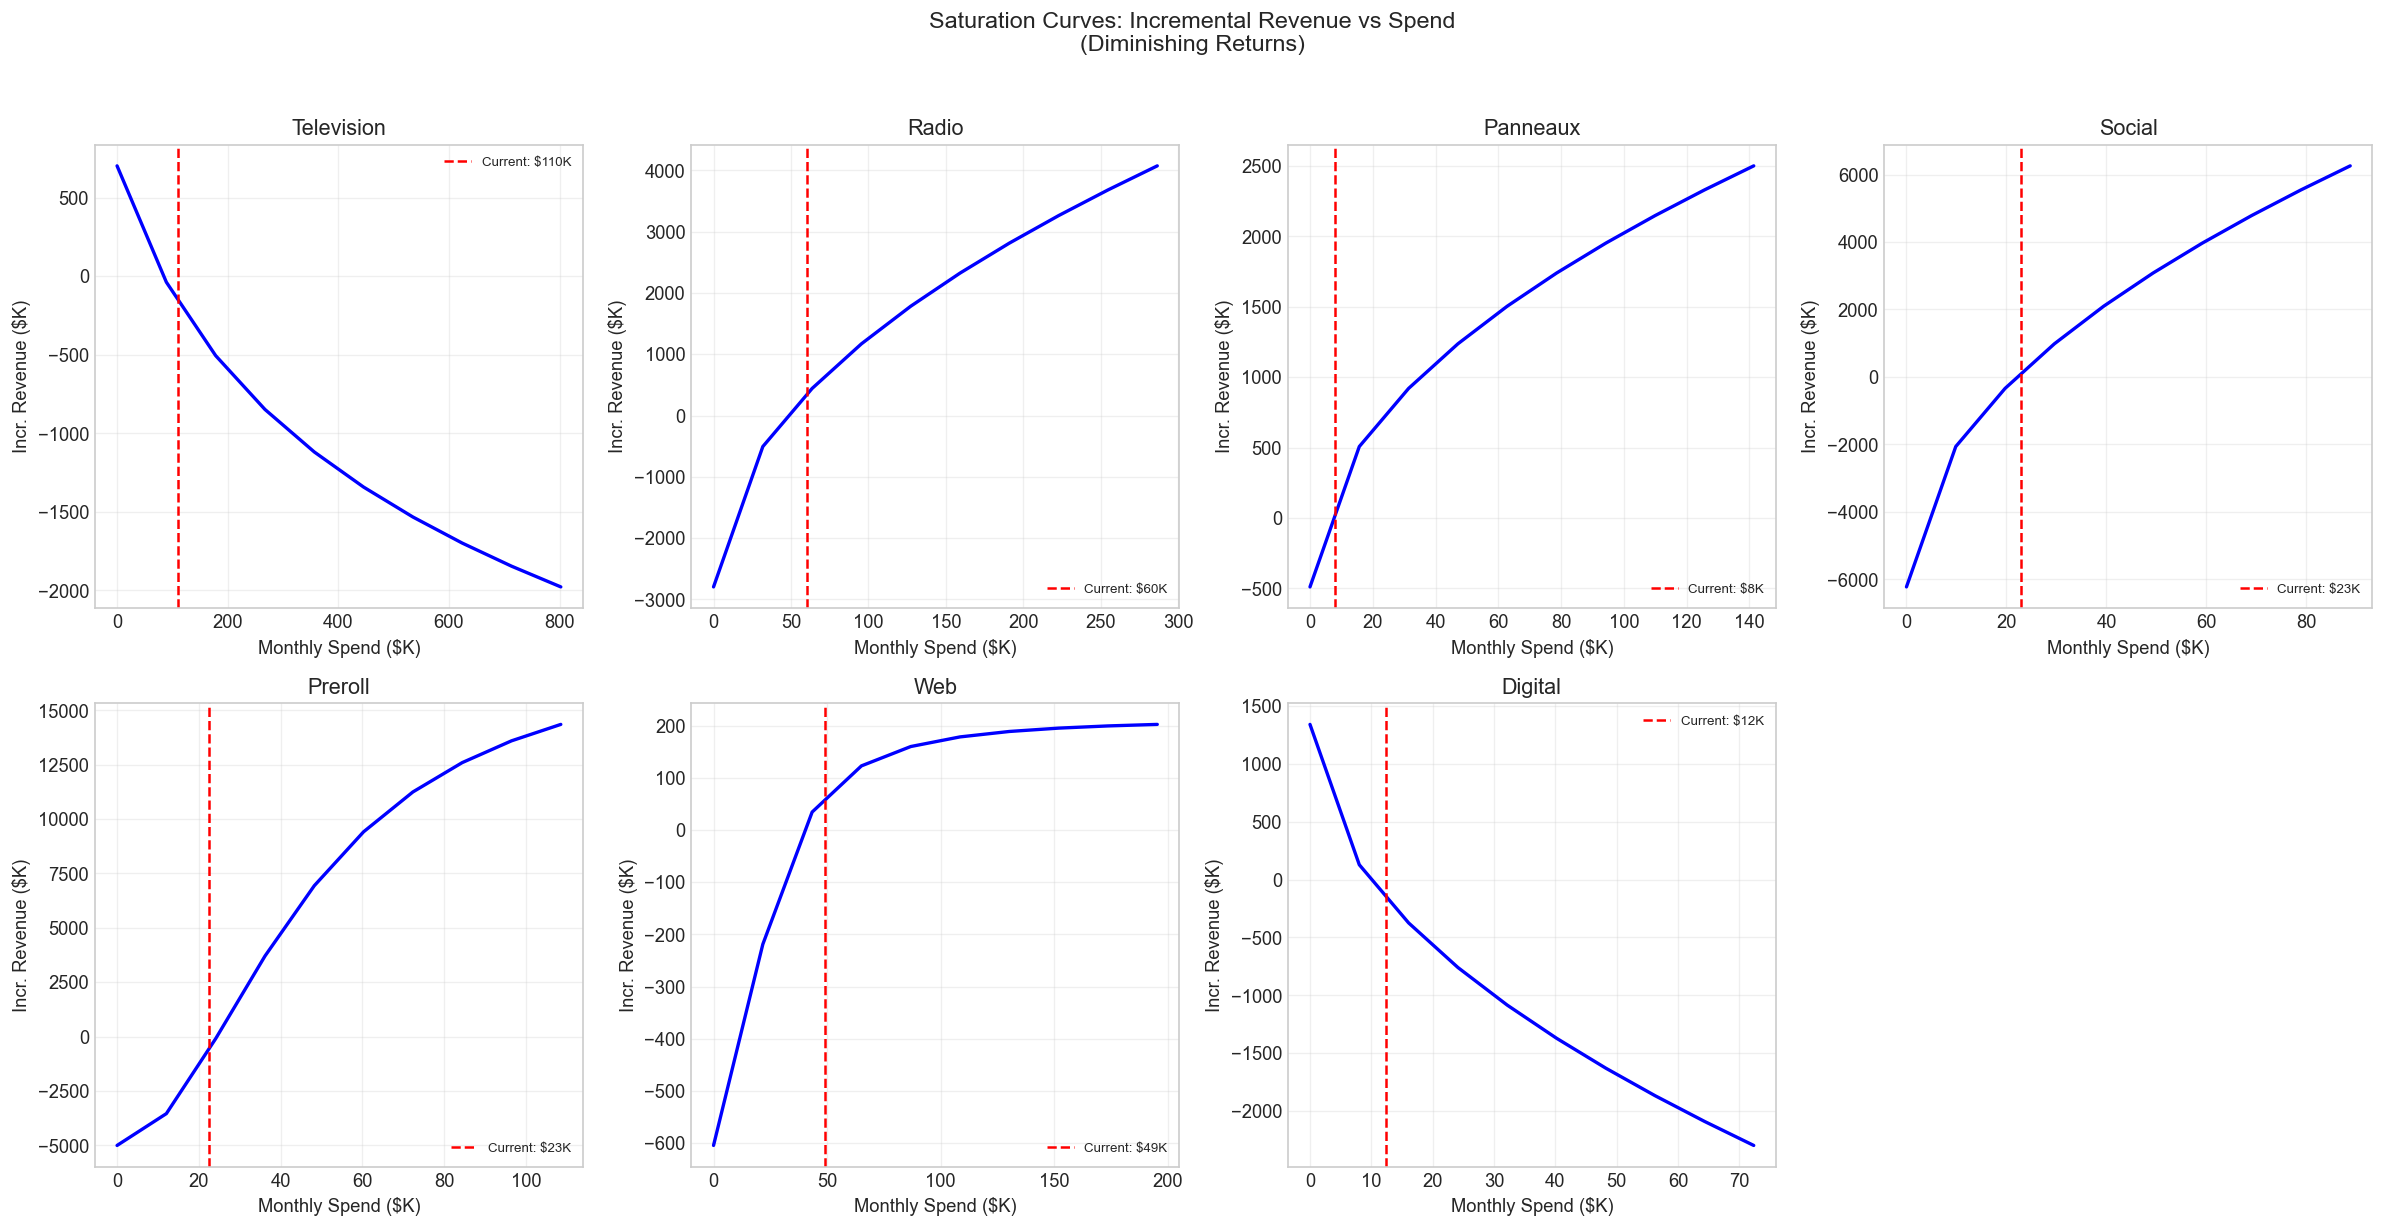

In [11]:
# ===================================================================
# 3-A  PLOT SATURATION CURVES FROM NB06 OUTPUT
# ===================================================================

# Filter for Total Revenue
sat_total = sat_curves_df[sat_curves_df['product'] == 'Total Revenue'].copy()

# Get current spend levels
current_spend = {}
for ch in model_params['media_channels']:
    spend_col = SPEND_TO_MEDIA.get('media_' + ch)
    if spend_col and spend_col in df.columns:
        current_spend[ch] = df[spend_col].mean()
    else:
        current_spend[ch] = 0

# Plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

channels = sat_total['channel'].unique()
for idx, ch in enumerate(channels):
    if idx >= len(axes) - 1:
        break
        
    ax = axes[idx]
    ch_data = sat_total[sat_total['channel'] == ch]
    label = CHANNEL_LABELS.get('media_' + ch, ch).split()[0]
    
    ax.plot(ch_data['spend'] / 1000, ch_data['incremental_revenue'] / 1000, 
            'b-', linewidth=2)
    
    # Mark current spend
    curr = current_spend.get(ch, 0)
    if curr > 0:
        ax.axvline(curr / 1000, color='red', linestyle='--', linewidth=1.5,
                   label=f'Current: ${curr/1000:.0f}K')
    
    ax.set_xlabel('Monthly Spend ($K)')
    ax.set_ylabel('Incr. Revenue ($K)')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[-1])

fig.suptitle('Saturation Curves: Incremental Revenue vs Spend\n(Diminishing Returns)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'mmm_saturation_curves.png', dpi=150)
plt.show()

In [ ]:
# ===================================================================
# 3-B  SATURATION ANALYSIS (RECOMPUTED)
# ===================================================================

print('Saturation Analysis (Recomputed — all values bounded [0, 100%]):')
print('=' * 70)
print(f'{"Channel":25s} {"Sat Type":>8s} {"Sat%":>8s} {"Interpretation":>25s}')
print('-' * 70)

for ch in MEDIA_CHANNELS:
    label = CHANNEL_LABELS.get(ch, ch)
    sat_pct = SATURATION_PCT[ch]
    sat_type = SATURATION_PARAMS[ch]['type']
    
    if sat_pct > 70:
        interpretation = 'Highly saturated'
    elif sat_pct > 40:
        interpretation = 'Moderately saturated'
    else:
        interpretation = 'Room to grow'
    
    print(f'{label:25s} {sat_type:>8s} {sat_pct:>7.1f}% {interpretation:>25s}')

---
## Section 4 — Budget Optimization

In [ ]:
# ===================================================================
# 4-A  RESPONSE FUNCTION CURVES (Non-Linear)
# ===================================================================
# Analogous to the "demand curves" in the professor's framework (slides 20-23).
# Each curve maps monthly spend → monthly revenue contribution via saturation.

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, ch in enumerate(MEDIA_CHANNELS):
    if idx >= 7:
        break
    ax = axes[idx]
    label = CHANNEL_LABELS.get(ch, ch)
    ch_short = ch.replace('media_', '')
    
    # Generate spend range: $0 to 3x current spend
    curr = current_spend.get(ch_short, 0)
    max_spend = max(curr * 3, 10000)
    spends = np.linspace(0, max_spend, 100)
    
    # Compute response at each spend level
    responses = [channel_response(s, ch) for s in spends]
    
    ax.plot(spends / 1000, np.array(responses) / 1000, 'b-', linewidth=2)
    
    # Mark current spend
    if curr > 0:
        curr_resp = channel_response(curr, ch)
        ax.plot(curr / 1000, curr_resp / 1000, 'ro', markersize=10, zorder=5)
        ax.axvline(curr / 1000, color='red', linestyle='--', linewidth=1, alpha=0.5)
        ax.annotate(f'Current\n${curr/1000:.0f}K', 
                    xy=(curr/1000, curr_resp/1000),
                    xytext=(10, 10), textcoords='offset points', fontsize=8)
    
    ax.set_xlabel('Monthly Spend ($K)')
    ax.set_ylabel('Revenue Contribution ($K/mo)')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[-1])

fig.suptitle('Channel Response Functions (Spend → Revenue)\nNon-linear: adstock + saturation + Ridge coefficient',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'mmm_response_curves.png', dpi=150)
plt.show()

In [14]:
# ===================================================================
# 4-B  CURRENT ALLOCATION
# ===================================================================

# Current monthly spend per channel
current_monthly = {}
for ch in model_params['media_channels']:
    spend_col = SPEND_TO_MEDIA.get('media_' + ch)
    if spend_col and spend_col in df.columns:
        current_monthly[ch] = df[spend_col].mean()
    else:
        current_monthly[ch] = 0

total_monthly_budget = sum(current_monthly.values())

print('Current Monthly Budget Allocation:')
print('=' * 60)
for ch, spend in sorted(current_monthly.items(), key=lambda x: -x[1]):
    label = CHANNEL_LABELS.get('media_' + ch, ch)
    pct = spend / total_monthly_budget * 100 if total_monthly_budget > 0 else 0
    print(f'  {label:25s}  ${spend:>10,.0f}  ({pct:>5.1f}%)')
print('-' * 60)
print(f'  {"TOTAL":25s}  ${total_monthly_budget:>10,.0f}')

Current Monthly Budget Allocation:
  Television                 $   109,693  ( 38.5%)
  Radio                      $    60,202  ( 21.1%)
  Web Banners                $    48,949  ( 17.2%)
  Social Media               $    22,984  (  8.1%)
  Preroll (Video)            $    22,574  (  7.9%)
  Digital Flyers             $    12,404  (  4.4%)
  Panneaux (Outdoor)         $     8,125  (  2.9%)
------------------------------------------------------------
  TOTAL                      $   284,931


In [ ]:
# ===================================================================
# 4-C  STEP 2 — CONSTRAINED OPTIMIZATION (LP/NLP ANALOGUE)
# ===================================================================
# Following the professor's framework (Teaching.pdf, slides 29-33):
#   Decision variables: x_i = monthly spend on channel i
#   Objective: maximize sum(channel_response(x_i))
#   Subject to business constraints from Club Piscine media team
#
# Constraints:
#   C1: sum(x_i) = total_monthly_budget          (budget equality)
#   C2: 40% ≤ traditional ≤ 60%                  (50/50 ±10% trad/digital)
#   C3: x_i ≥ $500 for all i                     (minimum per channel)
#   C4: x_i ≤ 50% of budget for all i            (no single-channel dominance)

channels = list(current_monthly.keys())
n_ch = len(channels)

# Traditional vs Digital channel indices
TRADITIONAL = ['television', 'radio', 'panneaux']
DIGITAL = ['social_media', 'preroll', 'banniere_web', 'circulaire_digitale']
trad_idx = [channels.index(ch) for ch in TRADITIONAL]
digi_idx = [channels.index(ch) for ch in DIGITAL]

def neg_total_response(x):
    """Negative total response (for minimization)."""
    spend_dict = {f'media_{ch}': max(xi, 0) for ch, xi in zip(channels, x)}
    return -total_response(spend_dict)

# Starting point: current allocation
x0 = np.array([current_monthly[ch] for ch in channels])

# Bounds: C3 (min $500) and C4 (max 50% of budget)
bounds = [(500, total_monthly_budget * 0.50) for _ in channels]

# Constraints
constraints = [
    # C1: Budget equality
    {'type': 'eq', 'fun': lambda x: np.sum(x) - total_monthly_budget},
    # C2: Traditional ≥ 40% of budget
    {'type': 'ineq', 'fun': lambda x: sum(x[i] for i in trad_idx) - 0.40 * total_monthly_budget},
    # C2: Traditional ≤ 60% of budget
    {'type': 'ineq', 'fun': lambda x: 0.60 * total_monthly_budget - sum(x[i] for i in trad_idx)},
]

print('Running constrained optimization...')
print(f'  Budget: ${total_monthly_budget:,.0f}/month')
print(f'  Channels: {n_ch}')
print(f'  Constraints: budget equality, 50/50 trad/digital (±10%), min $500, max 50%')
print()

# Try SLSQP first, fallback to trust-constr
result = minimize(
    neg_total_response, x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 2000, 'ftol': 1e-10}
)

if not result.success:
    print(f'  SLSQP failed ({result.message}), trying trust-constr...')
    from scipy.optimize import NonlinearConstraint
    result = minimize(
        neg_total_response, x0,
        method='trust-constr',
        bounds=bounds,
        constraints=[
            {'type': 'eq', 'fun': lambda x: np.sum(x) - total_monthly_budget},
            {'type': 'ineq', 'fun': lambda x: sum(x[i] for i in trad_idx) - 0.40 * total_monthly_budget},
            {'type': 'ineq', 'fun': lambda x: 0.60 * total_monthly_budget - sum(x[i] for i in trad_idx)},
        ],
        options={'maxiter': 2000}
    )

print(f'Optimization converged: {result.success}')
print(f'Message: {result.message}')

# Extract results
optimal_allocation = {ch: max(result.x[i], 0) for i, ch in enumerate(channels)}

# Verify constraints
opt_total = sum(optimal_allocation.values())
opt_trad = sum(optimal_allocation[ch] for ch in TRADITIONAL)
opt_digi = sum(optimal_allocation[ch] for ch in DIGITAL)
opt_min = min(optimal_allocation.values())
opt_max = max(optimal_allocation.values())

print(f'\nConstraint Check:')
print(f'  C1 Budget: ${opt_total:,.0f} (target: ${total_monthly_budget:,.0f}) {"PASS" if abs(opt_total - total_monthly_budget) < 1 else "FAIL"}')
print(f'  C2 Trad:   {opt_trad/opt_total*100:.1f}% (target: 40-60%) {"PASS" if 0.39*opt_total <= opt_trad <= 0.61*opt_total else "FAIL"}')
print(f'  C3 Min:    ${opt_min:,.0f} (target: ≥$500) {"PASS" if opt_min >= 499 else "FAIL"}')
print(f'  C4 Max:    ${opt_max:,.0f} ({opt_max/opt_total*100:.0f}%, target: ≤50%) {"PASS" if opt_max <= 0.51*opt_total else "FAIL"}')

In [ ]:
# ===================================================================
# 4-D  OPTIMIZATION RESULTS (NON-LINEAR RESPONSE)
# ===================================================================

# Compute contributions using channel_response (non-linear)
current_spend_dict = {f'media_{ch}': current_monthly[ch] for ch in channels}
optimal_spend_dict = {f'media_{ch}': optimal_allocation[ch] for ch in channels}

current_contribution = total_response(current_spend_dict)
optimal_contribution = total_response(optimal_spend_dict)
contribution_lift = optimal_contribution - current_contribution
lift_pct = (contribution_lift / abs(current_contribution) * 100) if abs(current_contribution) > 0 else 0

print('=' * 100)
print('BUDGET OPTIMIZATION RESULTS (Non-Linear Response Functions)')
print('=' * 100)
print(f'{"Channel":25s} {"Current":>12s} {"Optimal":>12s} {"Change":>12s} {"Change%":>10s} {"Curr Resp":>12s} {"Opt Resp":>12s}')
print('-' * 100)

opt_results = []
for ch in channels:
    label = CHANNEL_LABELS.get('media_' + ch, ch)
    current = current_monthly[ch]
    optimal = optimal_allocation[ch]
    change = optimal - current
    change_pct = (change / current * 100) if current > 0 else 0
    curr_resp = channel_response(current, f'media_{ch}')
    opt_resp = channel_response(optimal, f'media_{ch}')
    
    print(f'{label:25s} ${current:>10,.0f} ${optimal:>10,.0f} ${change:>+10,.0f} {change_pct:>+9.1f}% ${curr_resp:>10,.0f} ${opt_resp:>10,.0f}')
    
    opt_results.append({
        'channel': ch,
        'label': label,
        'current_spend': current,
        'optimal_spend': optimal,
        'change': change,
        'change_pct': change_pct,
        'current_response': curr_resp,
        'optimal_response': opt_resp,
    })

print('-' * 100)
curr_trad_pct = sum(current_monthly[ch] for ch in TRADITIONAL) / total_monthly_budget * 100
opt_trad_pct = opt_trad / opt_total * 100
print(f'{"TOTAL":25s} ${total_monthly_budget:>10,.0f} ${opt_total:>10,.0f} {"":>12s} {"":>10s} ${current_contribution:>10,.0f} ${optimal_contribution:>10,.0f}')
print(f'  Traditional/Digital:    {curr_trad_pct:.0f}/{100-curr_trad_pct:.0f}  →  {opt_trad_pct:.0f}/{100-opt_trad_pct:.0f}')
print()
print(f'Monthly Media Response (Current):   ${current_contribution:>12,.0f}')
print(f'Monthly Media Response (Optimal):   ${optimal_contribution:>12,.0f}')
print(f'Monthly Lift:                       ${contribution_lift:>+12,.0f} ({lift_pct:+.1f}%)')
print(f'Annualized Lift:                    ${contribution_lift * 12:>+12,.0f}')

opt_df = pd.DataFrame(opt_results)

In [ ]:
# ===================================================================
# 4-E  OPTIMIZATION VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Current vs Optimal Allocation
ax = axes[0]
x = np.arange(len(channels))
width = 0.35
ax.bar(x - width/2, [current_monthly[ch]/1000 for ch in channels], width,
       label='Current', color='steelblue', alpha=0.8)
ax.bar(x + width/2, [optimal_allocation[ch]/1000 for ch in channels], width,
       label='Optimal', color='forestgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([CHANNEL_LABELS.get('media_' + ch, ch).split()[0] for ch in channels],
                   rotation=45, ha='right')
ax.set_ylabel('Monthly Spend ($K)')
ax.set_title('Current vs Optimal Budget Allocation')
ax.legend()

# 2. Change in Spend
ax = axes[1]
changes = [opt_df[opt_df['channel'] == ch]['change'].values[0] / 1000 for ch in channels]
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in changes]
labels_short = [CHANNEL_LABELS.get('media_' + ch, ch).split()[0] for ch in channels]
ax.barh(labels_short, changes, color=colors, alpha=0.8)
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Change in Monthly Spend ($K)')
ax.set_title('Recommended Budget Reallocation')

# 3. Response Impact (non-linear)
ax = axes[2]
curr_resps = [channel_response(current_monthly[ch], f'media_{ch}') / 1000 for ch in channels]
opt_resps = [channel_response(optimal_allocation[ch], f'media_{ch}') / 1000 for ch in channels]
ax.bar(x - width/2, curr_resps, width, label='Current', color='steelblue', alpha=0.8)
ax.bar(x + width/2, opt_resps, width, label='Optimal', color='forestgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([CHANNEL_LABELS.get('media_' + ch, ch).split()[0] for ch in channels],
                   rotation=45, ha='right')
ax.set_ylabel('Monthly Response ($K)')
ax.set_title(f'Revenue Response: Current vs Optimal\n(Lift: {lift_pct:+.1f}%)')
ax.legend()

plt.tight_layout()
plt.savefig(figures_path / 'mmm_optimization_results.png', dpi=150)
plt.show()

---
## Section 5 — Scenario Analysis

In [ ]:
# ===================================================================
# 5-A  SCENARIO ANALYSIS (NON-LINEAR, RE-OPTIMIZED)
# ===================================================================
# At each budget level, re-run the full optimizer to find the best allocation.
# This produces diminishing returns (concave curve) as budget increases.

budget_multipliers = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5, 2.0]
scenario_results = []

for mult in budget_multipliers:
    scenario_budget = total_monthly_budget * mult
    
    # Scale current allocation as starting point
    x0_scenario = np.array([current_monthly[ch] * mult for ch in channels])
    
    # Bounds adjusted to scenario budget
    bounds_scenario = [(500, scenario_budget * 0.50) for _ in channels]
    
    # Re-run optimizer with same constraints
    constraints_scenario = [
        {'type': 'eq', 'fun': lambda x, b=scenario_budget: np.sum(x) - b},
        {'type': 'ineq', 'fun': lambda x, b=scenario_budget: sum(x[i] for i in trad_idx) - 0.40 * b},
        {'type': 'ineq', 'fun': lambda x, b=scenario_budget: 0.60 * b - sum(x[i] for i in trad_idx)},
    ]
    
    res = minimize(
        neg_total_response, x0_scenario,
        method='SLSQP',
        bounds=bounds_scenario,
        constraints=constraints_scenario,
        options={'maxiter': 2000, 'ftol': 1e-10}
    )
    
    opt_spend = {f'media_{ch}': max(res.x[i], 0) for i, ch in enumerate(channels)}
    opt_contribution = total_response(opt_spend)
    
    scenario_results.append({
        'budget_pct': mult * 100,
        'total_spend': scenario_budget,
        'contribution': opt_contribution,
        'roi': opt_contribution / scenario_budget if scenario_budget > 0 else 0,
        'converged': res.success,
    })

scenario_df = pd.DataFrame(scenario_results)

# Add marginal ROI (change in contribution / change in spend)
scenario_df['marginal_roi'] = scenario_df['contribution'].diff() / scenario_df['total_spend'].diff()

print('Scenario Analysis: Budget Scaling (Non-Linear, Re-Optimized)')
print('=' * 90)
print(f'{"Budget%":>8s} {"Monthly Spend":>14s} {"Contribution":>14s} {"Avg ROI":>10s} {"Marg ROI":>10s} {"Conv":>5s}')
print('-' * 90)
for _, row in scenario_df.iterrows():
    marg = f"{row['marginal_roi']:.2f}" if pd.notna(row['marginal_roi']) else 'N/A'
    print(f"{row['budget_pct']:>7.0f}% ${row['total_spend']:>12,.0f} ${row['contribution']:>12,.0f} {row['roi']:>10.2f} {marg:>10s} {'Yes' if row['converged'] else 'No':>5s}")

print()
print('Note: ROI decreases as budget increases (diminishing returns from saturation).')

In [ ]:
# ===================================================================
# 5-B  SCENARIO VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Contribution vs Budget (should be concave)
ax = axes[0]
ax.plot(scenario_df['total_spend'] / 1000, scenario_df['contribution'] / 1e6,
        'b-o', linewidth=2, markersize=8)
ax.axvline(total_monthly_budget / 1000, color='red', linestyle='--', label='Current Budget')
ax.set_xlabel('Monthly Media Spend ($K)')
ax.set_ylabel('Monthly Media Contribution ($M)')
ax.set_title('Media Contribution vs Budget\n(Concave = Diminishing Returns)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Average ROI vs Budget Level (should be decreasing)
ax = axes[1]
ax.plot(scenario_df['budget_pct'], scenario_df['roi'], 'g-o', linewidth=2, markersize=8)
ax.set_xlabel('Budget Level (% of Current)')
ax.set_ylabel('Average ROI ($/$ spent)')
ax.set_title('Average ROI vs Budget Level\n(Decreasing = Diminishing Returns)')
ax.grid(True, alpha=0.3)

# 3. Marginal ROI vs Budget Level (should be decreasing faster)
ax = axes[2]
valid_marg = scenario_df.dropna(subset=['marginal_roi'])
ax.plot(valid_marg['budget_pct'], valid_marg['marginal_roi'], 'r-o', linewidth=2, markersize=8)
ax.axhline(1, color='gray', linestyle='--', label='Break-even ($1)')
ax.set_xlabel('Budget Level (% of Current)')
ax.set_ylabel('Marginal ROI ($/$ of additional spend)')
ax.set_title('Marginal ROI vs Budget Level\n(How much does the next $1 return?)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / 'mmm_scenario_analysis.png', dpi=150)
plt.show()

---
## Section 6 — Executive Summary & Recommendations

In [ ]:
# ===================================================================
# 6-A  EXECUTIVE SUMMARY TABLE
# ===================================================================

summary_data = []
for _, roi_row in roi_df.iterrows():
    ch = roi_row['channel'].replace('media_', '')
    opt_row = opt_df[opt_df['channel'] == ch]
    
    change_pct = opt_row['change_pct'].values[0] if len(opt_row) > 0 else 0
    
    # Determine action
    if change_pct > 10:
        action = 'Increase'
    elif change_pct < -10:
        action = 'Decrease'
    else:
        action = 'Maintain'
    
    # CI significance
    sig = 'Yes' if (roi_row['marginal_ci_lo'] > 0 or roi_row['marginal_ci_hi'] < 0) else 'No'
    
    summary_data.append({
        'Channel': roi_row['label'],
        'Spend (3Y)': f"${roi_row['total_spend']:,.0f}",
        'Contribution (3Y)': f"${roi_row['total_contribution']:,.0f}",
        'ROAS': f"{roi_row['roas']:.1f}",
        'Significant': sig,
        'Saturation': f"{roi_row['saturation_pct']:.0f}%",
        'Opt Change': f"{change_pct:+.0f}%",
        'Action': action,
    })

summary_df = pd.DataFrame(summary_data)

print('=' * 120)
print('EXECUTIVE SUMMARY: MEDIA CHANNEL PERFORMANCE & OPTIMIZATION')
print('=' * 120)
print(summary_df.to_string(index=False))
print()
print('Notes:')
print('  - ROAS = marginal revenue per $1 spent at current spend levels')
print('  - Significant = 90% bootstrap CI excludes zero')
print('  - Optimization respects 50/50 traditional/digital constraint (±10%)')
print('  - Only Preroll (Video) is statistically significant')

In [ ]:
# ===================================================================
# 6-B  KEY METRICS SUMMARY
# ===================================================================

print('\n' + '=' * 70)
print('KEY METRICS SUMMARY')
print('=' * 70)

print(f'\nDATA:')
print(f'   Observations:           {len(df)} months (FY2023-FY2025)')
print(f'   Media Channels:         {len(MEDIA_CHANNELS)}')

print(f'\nFINANCIAL:')
print(f'   Total Revenue (3Y):     ${total_revenue:>15,.0f}')
print(f'   Total Media Spend (3Y): ${total_spend:>15,.0f}')
print(f'   Media Contribution:     ${TOTAL_MEDIA_CONTRIBUTION:>15,.0f} ({TOTAL_MEDIA_CONTRIBUTION/total_revenue*100:.1f}%)')

print(f'\nMODEL PERFORMANCE:')
r2 = model_params.get('ridge_r2', {}).get('Total Revenue', 'N/A')
r2_cv = model_params.get('ridge_r2_cv', {}).get('Total Revenue', 'N/A')
print(f'   R2 (in-sample):         {r2:.4f}')
print(f'   R2 (LOOCV):             {r2_cv:.4f}')

print(f'\nOPTIMIZATION:')
print(f'   Current Monthly Response:   ${current_contribution:>12,.0f}')
print(f'   Optimized Monthly Response: ${optimal_contribution:>12,.0f}')
print(f'   Monthly Lift:               ${contribution_lift:>+12,.0f} ({lift_pct:+.1f}%)')
print(f'   Annualized Lift:            ${contribution_lift * 12:>+12,.0f}')
print(f'   Constraints:                Budget equality, 50/50 trad/digital, min $500, max 50%')

# ===================================================================
# 6-C  IMPORTANT CAVEATS FOR INTERPRETATION
# ===================================================================
print('\n' + '=' * 70)
print('IMPORTANT CAVEATS FOR INTERPRETATION')
print('=' * 70)
print("""
MEASUREMENT LIMITATIONS:
  - GRPs/PEBs not comparable across markets, targets, or languages (#2-4)
  - Impressions are imperfect common denominator across channels (#5)
  - Premium video preroll >> standard display banner in attention/impact (#6)

UNMODELED VARIABLES:
  - Creative execution quality mediates media effectiveness (#9)
  - Production costs (80/20 media/production split) affect outcomes (#10)
  - Local store marketing not captured in centralized data (#14)
  - Competitive pressure (Trevi, Sima, big-box) affects demand (#18)

STRATEGIC DECISIONS (not ROI-driven):
  - Brand positioning: premium environments may appear less cost-efficient (#11)
  - Category visibility: 40% furniture, 30% pools, 20% spas, 5% BBQ, 5% other (#12)
  - Furniture is a growth-led strategic focus (pools/spas already "must-consider") (#13)
  - Deliberate fitness overinvestment for off-season traffic (#15)

OPERATIONAL CONSTRAINTS:
  - Installation/capacity limits may cap media-driven demand (#16)
  - Weather drives demand independently; campaigns planned centrally (#17)

STRUCTURAL CONSIDERATIONS:
  - Media mix evolving toward 50/50 trad/digital (non-stationarity) (#1)
  - Traditional media spill generates broad reach; digital is precise but bounded (#7-8)
""")

In [ ]:
# ===================================================================
# 6-D  SAVE OUTPUTS
# ===================================================================

# 1. ROI Results
roi_df.to_csv(processed_path / 'mmm_roi_results.csv', index=False)
print(f'Saved: {processed_path / "mmm_roi_results.csv"}')

# 2. Optimization Results
opt_df.to_csv(processed_path / 'mmm_optimization_results.csv', index=False)
print(f'Saved: {processed_path / "mmm_optimization_results.csv"}')

# 3. Scenario Analysis
scenario_df.to_csv(processed_path / 'mmm_scenario_analysis.csv', index=False)
print(f'Saved: {processed_path / "mmm_scenario_analysis.csv"}')

# 4. Executive Summary
summary_df.to_csv(processed_path / 'mmm_executive_summary.csv', index=False)
print(f'Saved: {processed_path / "mmm_executive_summary.csv"}')

# 5. Combined parameters
mmm_output = {
    'source_notebook': 'NB07_mmm_optimization',
    'model_source': 'NB06_causal_inference',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'framework': 'Two-step online optimization (Teaching.pdf)',
    'data_summary': {
        'n_months': len(df),
        'fiscal_years': sorted(df['year'].unique().tolist()),
        'total_revenue': float(total_revenue),
        'total_spend': float(total_spend),
        'media_contribution': float(TOTAL_MEDIA_CONTRIBUTION),
        'media_pct_of_revenue': float(TOTAL_MEDIA_CONTRIBUTION / total_revenue * 100),
    },
    'model_performance': {
        'r2': float(model_params['ridge_r2']['Total Revenue']),
        'r2_cv': float(model_params['ridge_r2_cv']['Total Revenue']),
    },
    'optimization': {
        'method': 'Non-linear (saturation curves) with SLSQP',
        'constraints': ['budget_equality', '50/50_trad_digital_pm10', 'min_$500', 'max_50%'],
        'current_monthly_budget': float(total_monthly_budget),
        'current_monthly_response': float(current_contribution),
        'optimal_monthly_response': float(optimal_contribution),
        'lift_pct': float(lift_pct),
        'optimal_allocation': {ch: float(v) for ch, v in optimal_allocation.items()},
    },
    'roi_by_channel': {row['channel']: float(row['roas']) for _, row in roi_df.iterrows()},
    'contribution_by_channel': {ch: float(CONTRIBUTION[ch]) for ch in MEDIA_CHANNELS},
    'saturation_pct_by_channel': {ch: float(SATURATION_PCT[ch]) for ch in MEDIA_CHANNELS},
}

with open(processed_path / 'mmm_final_output.json', 'w') as f:
    json.dump(mmm_output, f, indent=2)
print(f'Saved: {processed_path / "mmm_final_output.json"}')

In [ ]:
# ===================================================================
# 6-E  FINAL SUMMARY
# ===================================================================

print('\n' + '=' * 80)
print('  NOTEBOOK 07 — MMM ROI & OPTIMIZATION: COMPLETE')
print('=' * 80)
print()
print('FRAMEWORK: Two-Step Online Optimization (Teaching.pdf)')
print('  Step 1: Response Estimation — reconstructed NB06 Ridge pipeline')
print('  Step 2: Constrained Optimization — non-linear, with business constraints')
print()
print('KEY FINDINGS:')
top_roi = roi_df.iloc[0]
print(f'  Highest ROAS Channel:    {top_roi["label"]} (ROAS = {top_roi["roas"]:.1f})')
print(f'  Media % of Revenue:      {TOTAL_MEDIA_CONTRIBUTION/total_revenue*100:.1f}%')
print(f'  Optimization Lift:       {lift_pct:+.1f}% monthly (with 50/50 trad/digital constraint)')
print(f'  Scenario ROI:            Decreasing with budget (diminishing returns confirmed)')
print()
print('OUTPUT FILES:')
for f_name in ['mmm_roi_results.csv', 'mmm_optimization_results.csv',
               'mmm_scenario_analysis.csv', 'mmm_executive_summary.csv',
               'mmm_final_output.json']:
    print(f'  data/processed/{f_name}')
print()
print('FIGURES:')
for f in sorted(figures_path.glob('mmm_*.png')):
    print(f'  reports/figures/{f.name}')

---
## Appendix: Methodology Notes

### Two-Step Online Optimization Framework (Teaching.pdf)

Following the professor's framework (slides 17-19, 29-33):

1. **Step 1 — Response Estimation**: Reconstruct NB06's Ridge regression pipeline to recover channel-specific response functions:
   - `spend → adstock (geometric decay) → saturation (Hill/Log/Power) → beta_orig × saturated = revenue`
   - Unstandardize coefficients: `beta_orig = beta_std / std(S_j)` since NB06 standardizes X but not y
   - Verify reconstructed coefficients match NB06's saved values

2. **Step 2 — Constrained Optimization**: Solve a non-linear program (NLP) analogous to the LP in slides 29-33:
   - **Decision variables**: monthly spend per channel
   - **Objective**: maximize total revenue response (non-linear via saturation curves)
   - **Constraints**: budget equality, 50/50 trad/digital (±10%), min $500/channel, max 50%/channel

### Business Constraints (18 from Club Piscine Media Team)

Hard constraints coded into optimizer:
- Budget equality, 50/50 traditional/digital split, per-channel min/max

Soft constraints presented as caveats:
- GRP/impression comparability limitations, creative execution, production costs,
  brand positioning, category visibility allocation (40/30/20/5/5),
  local store marketing, fitness overinvestment, capacity constraints,
  weather variability, competitive pressure

### Saturation Functions
- **Hill** (Preroll, Web Banners): `x^α / (x^α + K^α)` — bounded [0, 1]
- **Log** (Television): `log(1 + x/scale)` — unbounded but diminishing
- **Power** (Radio, Panneaux, Social, Digital Flyers): `x^β` — unbounded but diminishing (β = 0.5)